In [147]:
import pandas as pd

In [148]:
import numpy as np

In [149]:
import matplotlib.pyplot as plt

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subject_id         100 non-null    int64
 1   gender             100 non-null    str  
 2   anchor_age         100 non-null    int64
 3   anchor_year        100 non-null    int64
 4   anchor_year_group  100 non-null    str  
 5   dod                31 non-null     str  
dtypes: int64(3), str(3)
memory usage: 6.3 KB


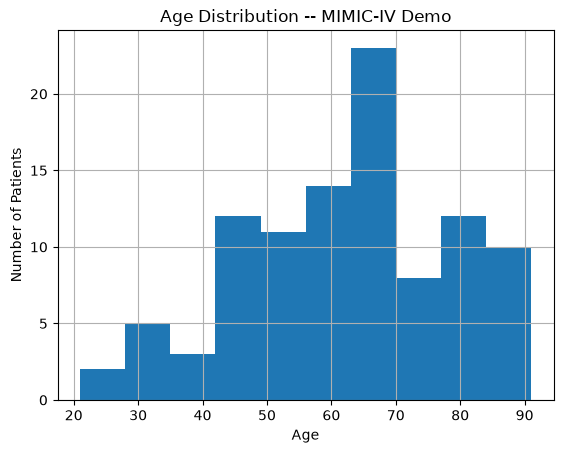

In [150]:

from pathlib import Path
import matplotlib.pyplot as plt
data_file = Path("../data/hosp/patients.csv")

if not data_file.exists():
    data_file = Path("data/hosp/patients.csv")

if not data_file.exists():
    raise FileNotFoundError(
        f"patients.csv was not found. Checked: "
        f"{Path('../data/hosp/patients.csv').resolve()} and "
        f"{Path('data/hosp/patients.csv').resolve()}"
    )

patients = pd.read_csv(data_file)
patients.head()
patients.shape
patients.columns
patients.info()
patients["gender"].value_counts()
patients["anchor_age"].describe()
patients["anchor_age"].hist()

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution -- MIMIC-IV Demo")
plt.show()

##Understanding the MIMIC-IV relational structure

In [151]:
import pandas as pd
data_root = data_file.parent.parent

patients= pd.read_csv(data_root/"hosp"/"patients.csv")
admissions = pd.read_csv(data_root / "hosp" / "admissions.csv")
icustays = pd.read_csv(data_root / "icu" / "icustays.csv")

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("ICU stays:", icustays.shape)

patients.head()
patients.columns.tolist()
patients.info()
print("Rows:",len(patients))
print("Unique patients:",patients["subject_id"].nunique())

admissions.head()
admissions.columns.tolist()
print("Hospital admissions:",len(admissions))
print("Unique Patients:",admissions["subject_id"].nunique())
print("Unique hadm_id:",admissions["hadm_id"].nunique())
admissions_per_patient=admissions.groupby("subject_id")["hadm_id"].nunique().sort_values(ascending=False)

admissions_per_patient.head(10)
admissions["admittime"] = pd.to_datetime(admissions["admittime"])
import pandas as pd
data_root = data_file.parent.parent

patients= pd.read_csv(data_root/"hosp"/"patients.csv")
admissions = pd.read_csv(data_root / "hosp" / "admissions.csv")
icustays = pd.read_csv(data_root / "icu" / "icustays.csv")

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("ICU stays:", icustays.shape)

patients.head()
patients.columns.tolist()
patients.info()
print("Rows:",len(patients))
print("Unique patients:",patients["subject_id"].nunique())

admissions.head()
admissions.columns.tolist()
print("Hospital admissions:",len(admissions))
print("Unique Patients:",admissions["subject_id"].nunique())
print("Unique hadm_id:",admissions["hadm_id"].nunique())
admissions_per_patient=admissions.groupby("subject_id")["hadm_id"].nunique().sort_values(ascending=False)

admissions_per_patient.head(10)
admissions["admittime"] = pd.to_datetime(admissions["admittime"])
admissions["dischtime"] = pd.to_datetime(admissions["dischtime"])
admissions["hospital_los_days"] = (
    admissions["dischtime"] - admissions["admittime"]
).dt.total_seconds() / (24 * 60 * 60)
admissions[
    ["subject_id", "hadm_id", "admittime",
     "dischtime", "hospital_los_days"]
].head()
admissions["hospital_los_days"].describe()
icustays.head()
icustays.columns.tolist()
print("ICU Stays:",len(icustays))
print("Unique ICU patients:",icustays["subject_id"].nunique())
icustays["los"].describe()

icu_admissions = icustays.merge(
    admissions,
    on=["subject_id", "hadm_id"],
    how="left"
)
icu_admissions.shape
icu_admissions[
    [
        "subject_id",
        "hadm_id",
        "stay_id",
        "admittime",
        "intime",
        "outtime",
        "dischtime"
    ]
].head()
cohort_preview = icustays.merge(
    admissions,
    on=["subject_id", "hadm_id"],
    how="left"
).merge(
    patients,
    on="subject_id",
    how="left"
)
cohort_preview[
    [
        "subject_id",
        "hadm_id",
        "stay_id",
        "gender",
        "anchor_age",
        "intime",
        "outtime",
        "los"
    ]
].head(10)
example_patient = icustays["subject_id"].iloc[0]

print(example_patient)
patients[
    patients["subject_id"] == example_patient
]
admissions[
    admissions["subject_id"] == example_patient
][
    ["hadm_id", "admittime", "dischtime", "admission_type"]
]
icustays[
    icustays["subject_id"] == example_patient
][
    [
        "hadm_id",
        "stay_id",
        "first_careunit",
        "intime",
        "outtime",
        "los"
    ]
]
print("ICU rows before merge:", len(icustays))
print("Rows after merge:", len(cohort_preview))
cohort_preview[
    ["subject_id", "hadm_id", "stay_id"]
].isna().sum()
cohort_preview["stay_id"].duplicated().sum()

chartevents_file = data_root / "icu" / "chartevents.csv"

if not chartevents_file.is_file():
    raise FileNotFoundError(f"Chartevents file not found: {chartevents_file.resolve()}")

with chartevents_file.open("rb") as file:
    compression = "gzip" if file.read(2) == b"\x1f\x8b" else None

chartevents = pd.read_csv(
    chartevents_file,
    compression=compression,
    low_memory=False
)

print("Chartevents:", chartevents.shape)

d_items = pd.read_csv(
    "../data/icu/d_items.csv"
)

labevents = pd.read_csv(
    "../data/hosp/labevents.csv",
    low_memory=False
)

d_labitems = pd.read_csv(
    "../data/hosp/d_labitems.csv"
)

print("Chartevents:", chartevents.shape)
print("ICU dictionary:", d_items.shape)
print("Labevents:", labevents.shape)
print("Lab dictionary:", d_labitems.shape)

def search_icu_items(term):
    return d_items[
d_items[
    d_items["label"].str.contains(
        "heart rate",
        case=False,
        na=False
    )
][["itemid", "label", "category", "unitname"]]]

chartevents.head()
chartevents.columns.tolist()
def search_icu_items(term):
    mask = d_items["label"].astype("string").str.contains(
        term,
        case=False,
        na=False,
        regex=False,
    )
    return d_items.loc[
        mask,
        ["itemid", "label", "category", "unitname"],
    ]

search_icu_items("heart rate")
search_icu_items("respiratory")
search_icu_items("oxygen saturation")
search_icu_items("blood pressure")
search_icu_items("temperature")
search_icu_items("GCS")

def inspect_icu_variable(term):

    candidates = d_items[
        d_items["label"].str.contains(
            term,
            case=False,
            na=False
        )
    ].copy()

    counts = (
        chartevents
        .groupby("itemid")
        .agg(
            measurements=("itemid", "size"),
            patients=("subject_id", "nunique"),
            icu_stays=("stay_id", "nunique")
        )
        .reset_index()
    )

    result = candidates.merge(
        counts,
        on="itemid",
        how="left"
    )

    result[
        ["measurements", "patients", "icu_stays"]
    ] = result[
        ["measurements", "patients", "icu_stays"]
    ].fillna(0)

    return result[
        [
            "itemid",
            "label",
            "category",
            "unitname",
            "measurements",
            "patients",
            "icu_stays"
        ]
    ].sort_values(
        "measurements",
        ascending=False
    )

d_items[
    d_items["label"].str.contains(
        "saturation",
        case=False,
        na=False
    )
][
    [
        "itemid",
        "label",
        "abbreviation",
        "category",
        "unitname"
    ]
].to_string(index=False)

d_items[
    d_items["label"].str.contains(
        "spo2",
        case=False,
        na=False
    )
][
    [
        "itemid",
        "label",
        "abbreviation",
        "category",
        "unitname"
    ]
].to_string(index=False)
d_items[
    d_items["label"].str.contains(
        "oxygen",
        case=False,
        na=False
    )
][
    [
        "itemid",
        "label",
        "abbreviation",
        "category",
        "unitname"
    ]
].to_string(index=False)

# 220274 is arterial pH, not SpO2. Use the pulse-oximetry item.
spo2_items = d_items.loc[
    d_items["label"].astype("string").str.contains(
        r"oxygen saturation|o2 saturation|spo2",
        case=False,
        na=False,
        regex=True,
    )
]

spo2_items
inspect_icu_variable("heart rate")
inspect_icu_variable("respiratory rate")
inspect_icu_variable("SpO2")
inspect_icu_variable("systolic")
inspect_icu_variable("diastolic")
inspect_icu_variable("temperature")
inspect_icu_variable("GCS")

inspect_icu_variable("GCS")
# Identify the standard Heart Rate item robustly.
heart_rate_items = d_items.loc[
    d_items["label"]
    .astype("string")
    .str.strip()
    .str.casefold()
    .eq("heart rate"),
    ["itemid", "label"],
].copy()

if heart_rate_items.empty:
    raise ValueError("No Heart Rate item found in d_items.")

HR_ITEMID = (
    220045
    if (heart_rate_items["itemid"] == 220045).any()
    else heart_rate_items["itemid"].iloc[0]
)

heart_rate = chartevents.loc[
    pd.to_numeric(chartevents["itemid"], errors="coerce") == HR_ITEMID
].copy()

heart_rate["charttime"] = pd.to_datetime(
    heart_rate["charttime"],
    errors="coerce",
)
heart_rate["valuenum"] = pd.to_numeric(
    heart_rate["valuenum"],
    errors="coerce",
)

heart_rate = heart_rate.dropna(
    subset=["charttime", "valuenum"]
)
heart_rate[
    [
        "subject_id",
        "stay_id",
        "charttime",
        "valuenum",
        "valueuom"
    ]
].head(20)
heart_rate["valuenum"].describe()
heart_rate["valueuom"].value_counts(dropna=False)

labevents.head()
labevents.columns.tolist()
d_labitems.head()
d_labitems.columns.tolist()
def search_lab_items(term):
    return d_labitems[
        d_labitems["label"].str.contains(
            term,
            case=False,
            na=False
        )
    ][
        ["itemid", "label", "fluid", "category"]
    ]
search_lab_items("creatinine")
search_lab_items("white blood")
search_lab_items("hemoglobin")
search_lab_items("platelet")
search_lab_items("sodium")
search_lab_items("potassium")
search_lab_items("bicarbonate")
search_lab_items("glucose")
search_lab_items("lactate")

def inspect_lab_variable(term):

    candidates = d_labitems[
        d_labitems["label"].str.contains(
            term,
            case=False,
            na=False
        )
    ].copy()

    counts = (
        labevents
        .groupby("itemid")
        .agg(
            measurements=("itemid", "size"),
            patients=("subject_id", "nunique"),
            admissions=("hadm_id", "nunique")
        )
        .reset_index()
    )

    result = candidates.merge(
        counts,
        on="itemid",
        how="left"
    )

    result[
        ["measurements", "patients", "admissions"]
    ] = result[
        ["measurements", "patients", "admissions"]
    ].fillna(0)

    return result[
        [
            "itemid",
            "label",
            "fluid",
            "category",
            "measurements",
            "patients",
            "admissions"
        ]
    ].sort_values(
        "measurements",
        ascending=False
    )

inspect_lab_variable("creatinine")
inspect_lab_variable("white blood")
inspect_lab_variable("hemoglobin")
inspect_lab_variable("platelet")
inspect_lab_variable("sodium")
inspect_lab_variable("potassium")
inspect_lab_variable("bicarbonate")
inspect_lab_variable("glucose")
inspect_lab_variable("lactate")


Patients: (100, 6)
Admissions: (275, 16)
ICU stays: (140, 8)
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subject_id         100 non-null    int64
 1   gender             100 non-null    str  
 2   anchor_age         100 non-null    int64
 3   anchor_year        100 non-null    int64
 4   anchor_year_group  100 non-null    str  
 5   dod                31 non-null     str  
dtypes: int64(3), str(3)
memory usage: 6.3 KB
Rows: 100
Unique patients: 100
Hospital admissions: 275
Unique Patients: 100
Unique hadm_id: 275
Patients: (100, 6)
Admissions: (275, 16)
ICU stays: (140, 8)
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subject_id         100 non-null    int64
 1   gender             100 non-null    str  

,itemid,label,fluid,category,measurements,patients,admissions
0,50813,Lactate,Blood,Blood Gas,758.0,83.0,120.0
2,50954,Lactate Dehydrogenase (LD),Blood,Chemistry,663.0,59.0,98.0
6,51054,"Lactate Dehydrogenase, Pleural",Pleural,Chemistry,9.0,8.0,7.0
5,50843,"Lactate Dehydrogenase, Ascites",Ascites,Chemistry,7.0,5.0,6.0
3,53154,Lactate,Blood,Chemistry,0.0,0.0,0.0
1,52442,Lactate,Blood,Blood Gas,0.0,0.0,0.0
4,51944,"Lactate Dehydrogenase, Stool",Stool,Chemistry,0.0,0.0,0.0
7,51795,"Lactate Dehydrogenase, CSF",Cerebrospinal Fluid,Chemistry,0.0,0.0,0.0


## Candidate predictors

### Vital signs
- Heart rate
- Respiratory rate
- SpO2
- Systolic BP
- Diastolic BP
- Mean arterial pressure
- Temperature
- GCS

### Laboratory measurements
- Creatinine
- WBC
- Hemoglobin
- Platelets
- Sodium
- Potassium
- Bicarbonate
- Glucose
- Lactate

In [152]:
icu_subjects = set(icustays["subject_id"].unique())
icu_labs = labevents[
    labevents["subject_id"].isin(icu_subjects)
].copy()
print("All lab events:", len(labevents))
print("Lab events belonging to ICU patients:", len(icu_labs))

inspect_icu_variable("heart rate")
inspect_icu_variable("respiratory rate")
inspect_icu_variable("SpO2")
inspect_icu_variable("systolic")
inspect_icu_variable("temperature")
inspect_icu_variable("GCS")

inspect_lab_variable("creatinine")
inspect_lab_variable("white blood")
inspect_lab_variable("hemoglobin")
inspect_lab_variable("sodium")
inspect_lab_variable("potassium")
inspect_lab_variable("lactate")

All lab events: 107727
Lab events belonging to ICU patients: 107727


,itemid,label,fluid,category,measurements,patients,admissions
0,50813,Lactate,Blood,Blood Gas,758.0,83.0,120.0
2,50954,Lactate Dehydrogenase (LD),Blood,Chemistry,663.0,59.0,98.0
6,51054,"Lactate Dehydrogenase, Pleural",Pleural,Chemistry,9.0,8.0,7.0
5,50843,"Lactate Dehydrogenase, Ascites",Ascites,Chemistry,7.0,5.0,6.0
3,53154,Lactate,Blood,Chemistry,0.0,0.0,0.0
1,52442,Lactate,Blood,Blood Gas,0.0,0.0,0.0
4,51944,"Lactate Dehydrogenase, Stool",Stool,Chemistry,0.0,0.0,0.0
7,51795,"Lactate Dehydrogenase, CSF",Cerebrospinal Fluid,Chemistry,0.0,0.0,0.0


### Lactate

Blood lactate was identified using itemid 50813.

- Label: Lactate
- Fluid: Blood
- Category: Blood Gas
- Measurements available: 758
- Patients represented: 83
- Admissions represented: 120

Itemid 50813 was selected as the candidate lactate variable.
Lactate dehydrogenase measurements were excluded because they
represent a different biochemical marker.

Final inclusion in the prediction model will depend on availability
within the subsequently defined observation windows.

In [153]:
LACTATE_ITEMID = 50813
HR_ITEMID = 220045
RR_ITEMID = 220210
SPO2_ITEMID = 220277
SBP_ITEMID = 220179
DBP_ITEMID = 220180
TEMP_ITEMID = 223954

def inspect_selected_vital(name, itemid):
    
    data = chartevents[
        chartevents["itemid"] == itemid
    ].copy()

    print(f"===== {name} =====")
    print(f"Item ID: {itemid}")
    print(f"Measurements: {len(data)}")
    print(f"Patients: {data['subject_id'].nunique()}")
    print(f"ICU stays: {data['stay_id'].nunique()}")
    print(f"Missing valuenum: {data['valuenum'].isna().sum()}")

    print("\nUnits:")
    print(data["valueuom"].value_counts(dropna=False))

    print("\nDistribution:")
    print(data["valuenum"].describe())

    return data
heart_rate = inspect_selected_vital(
    "Heart Rate",
    HR_ITEMID
)
resp_rate = inspect_selected_vital(
    "Respiratory Rate",
    RR_ITEMID
)
spo2 = inspect_selected_vital(
    "SpO2",
    SPO2_ITEMID
)
sbp = inspect_selected_vital(
    "Systolic Blood Pressure",
    SBP_ITEMID
)
dbp = inspect_selected_vital(
    "Diastolic Blood Pressure",
    DBP_ITEMID
)
lactate = labevents[
    labevents["itemid"] == LACTATE_ITEMID
].copy()

lactate[
    [
        "subject_id",
        "hadm_id",
        "charttime",
        "valuenum",
        "valueuom"
    ]
].head(20)
lactate["valuenum"].describe()
lactate["valueuom"].value_counts(dropna=False)
lactate["valuenum"].isna().sum()

predictor_dictionary = pd.DataFrame({
    "variable": [
        "Heart Rate",
        "Respiratory Rate",
        "SpO2",
        "Systolic BP",
        "Diastolic BP",
        "Temperature",
        "GCS",
        "Creatinine",
        "WBC",
        "Hemoglobin",
        "Platelets",
        "Sodium",
        "Potassium",
        "Bicarbonate",
        "Glucose",
        "Lactate"
    ],

    "source": [
        "chartevents",
        "chartevents",
        "chartevents",
        "chartevents",
        "chartevents",
        "chartevents",
        "chartevents",
        "labevents",
        "labevents",
        "labevents",
        "labevents",
        "labevents",
        "labevents",
        "labevents",
        "labevents",
        "labevents"
    ]
})

predictor_dictionary

===== Heart Rate =====
Item ID: 220045
Measurements: 13913
Patients: 100
ICU stays: 140
Missing valuenum: 0

Units:
valueuom
bpm    13913
Name: count, dtype: int64

Distribution:
count    13913.000000
mean        91.122332
std         18.689358
min          0.000000
25%         78.000000
50%         90.000000
75%        104.000000
max        200.000000
Name: valuenum, dtype: float64
===== Respiratory Rate =====
Item ID: 220210
Measurements: 13913
Patients: 100
ICU stays: 140
Missing valuenum: 0

Units:
valueuom
insp/min    13913
Name: count, dtype: int64

Distribution:
count    13913.000000
mean        19.953425
std          5.552521
min          0.000000
25%         16.000000
50%         20.000000
75%         23.000000
max         58.000000
Name: valuenum, dtype: float64
===== SpO2 =====
Item ID: 220277
Measurements: 13540
Patients: 100
ICU stays: 140
Missing valuenum: 0

Units:
valueuom
%    13540
Name: count, dtype: int64

Distribution:
count    13540.000000
mean        96.811004
st

,variable,source
0,Heart Rate,chartevents
1,Respiratory Rate,chartevents
2,SpO2,chartevents
3,Systolic BP,chartevents
4,Diastolic BP,chartevents
5,Temperature,chartevents
6,GCS,chartevents
7,Creatinine,labevents
8,WBC,labevents
9,Hemoglobin,labevents


### Preliminary data-quality observations

Heart rate (220045) and respiratory rate (220210) had excellent
coverage across all 100 patients. However, both variables contained
recorded values of zero.

These values will be investigated during the data-cleaning stage
before defining physiologically plausible ranges.

In [154]:
heart_rate[
    heart_rate["valuenum"] == 0
][
    ["subject_id", "stay_id", "charttime", "valuenum"]
]
resp_rate[
    resp_rate["valuenum"] == 0
][
    ["subject_id", "stay_id", "charttime", "valuenum"]
]

,subject_id,stay_id,charttime,valuenum
6826,10005348,34629895,2130-10-27 18:15:00,0.0
6855,10005348,34629895,2130-10-27 20:15:00,0.0
6873,10005348,34629895,2130-10-27 21:15:00,0.0
7078,10005348,34629895,2130-10-27 18:30:00,0.0
7086,10005348,34629895,2130-10-27 19:30:00,0.0
7244,10005348,34629895,2130-10-27 18:45:00,0.0
7278,10005348,34629895,2130-10-27 19:46:00,0.0
10188,10006053,34617352,2111-11-15 17:00:00,0.0
167167,10037975,39061571,2185-01-19 08:00:00,0.0
167294,10037975,39061571,2185-01-19 09:00:00,0.0


### Investigation of zero HR and RR values

In [155]:
hr_zero_count = (heart_rate["valuenum"] == 0).sum()
rr_zero_count = (resp_rate["valuenum"] == 0).sum()

print("Heart Rate zero values:", hr_zero_count)
print("Respiratory Rate zero values:", rr_zero_count)

hr_zero_pct = (heart_rate["valuenum"] == 0).mean() * 100
rr_zero_pct = (resp_rate["valuenum"] == 0).mean() * 100

print(f"HR zero values: {hr_zero_count} ({hr_zero_pct:.2f}%)")
print(f"RR zero values: {rr_zero_count} ({rr_zero_pct:.2f}%)")

hr_zero_patients = heart_rate.loc[
    heart_rate["valuenum"] == 0, "subject_id"
].nunique()

rr_zero_patients = resp_rate.loc[
    resp_rate["valuenum"] == 0, "subject_id"
].nunique()

hr_zero_stays = heart_rate.loc[
    heart_rate["valuenum"] == 0, "stay_id"
].nunique()

rr_zero_stays = resp_rate.loc[
    resp_rate["valuenum"] == 0, "stay_id"
].nunique()

zero_summary = pd.DataFrame({
    "Variable": ["Heart Rate", "Respiratory Rate"],
    "Item ID": [HR_ITEMID, RR_ITEMID],
    "Total measurements": [len(heart_rate), len(resp_rate)],
    "Zero measurements": [hr_zero_count, rr_zero_count],
    "Zero percentage": [hr_zero_pct, rr_zero_pct],
    "Patients affected": [hr_zero_patients, rr_zero_patients],
    "ICU stays affected": [hr_zero_stays, rr_zero_stays]
})

zero_summary

Heart Rate zero values: 3
Respiratory Rate zero values: 47
HR zero values: 3 (0.02%)
RR zero values: 47 (0.34%)


,Variable,Item ID,Total measurements,Zero measurements,Zero percentage,Patients affected,ICU stays affected
0,Heart Rate,220045,13913,3,0.021563,2,2
1,Respiratory Rate,220210,13913,47,0.337814,15,15


### Data-quality finding

Zero-valued measurements were identified for heart rate and
respiratory rate. These measurements were retained during the
exploratory stage and flagged for further investigation during
data preprocessing.

No values were removed at this stage.